# Hoja de trabajo #2: Transformers y mecanismos de atención
**CC3092 – Deep Learning y Sistemas Inteligentes**

Contenido del notebook:

0. Configuración
1. Ejercicio a mano (atención con números pequeños) verificado con NumPy
2. Verificación de √d_k: varianza de q·k y saturación de la softmax
3. Atención en PyTorch: `F.scaled_dot_product_attention`, `nn.MultiheadAttention`, `nn.TransformerEncoderLayer`
4. Costo computacional: tiempo y memoria vs. longitud de la secuencia
5. Visualización de atención en BERT y GPT-2
   - 5.1 Mapas de calor de 4 cabezas
   - 5.2 Par «animal» / «street» en BERT
   - 5.3 GPT-2: matriz triangular y *attention sink*
   - 5.4 Entropía por capa (BERT vs. GPT-2)
   - 5.5 (Opcional) bertviz



## 0. Configuración

In [ ]:

import math, time, os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
os.makedirs("figs", exist_ok=True)
print("torch", torch.__version__)

torch 2.14.1+cpu


## 1. Ejercicio 

Secuencia de n = 3 tokens con d_k = d_v = 2. Dados

$$
Q=K=\begin{pmatrix}1&0\\0&1\\1&1\end{pmatrix},\qquad
V=\begin{pmatrix}1&2\\3&4\\5&6\end{pmatrix}
$$

calculamos paso a paso $\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$.

1. Puntajes crudos $S = QK^\top$.
2. Escalado $S/\sqrt{2}$.
3. Softmax por fila.
4. Salida $A V$.
5. Versión causal (máscara triangular inferior).

Abajo se hace en NumPy para **verificar** el procedimiento hecho a mano que aparece en el informe.

In [2]:
Q = np.array([[1,0],[0,1],[1,1]], dtype=float)
K = Q.copy()
V = np.array([[1,2],[3,4],[5,6]], dtype=float)
dk = Q.shape[1]

def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

S = Q @ K.T
S_scaled = S / math.sqrt(dk)
A = softmax(S_scaled)
out = A @ V

np.set_printoptions(precision=4, suppress=True)
print("S = QK^T\n", S)
print("\nS / sqrt(d_k)\n", S_scaled)
print("\nA = softmax(S/sqrt(d_k))\n", A, "\nsuma de filas:", A.sum(1))
print("\nSalida A V\n", out)

# Version causal
mask = np.tril(np.ones((3,3), dtype=bool))
S_causal = np.where(mask, S_scaled, -np.inf)
A_causal = softmax(S_causal)
print("\nA causal\n", A_causal)
print("\nSalida causal\n", A_causal @ V)

# Verificacion cruzada con PyTorch
t = torch.tensor
ref = F.scaled_dot_product_attention(t(Q)[None], t(K)[None], t(V)[None])[0].numpy()
ref_c = F.scaled_dot_product_attention(t(Q)[None], t(K)[None], t(V)[None], is_causal=True)[0].numpy()
print("\n|NumPy - PyTorch| (sin mascara):", np.abs(out-ref).max())
print("|NumPy - PyTorch| (causal):     ", np.abs(A_causal@V-ref_c).max())

S = QK^T
 [[1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 2.]]

S / sqrt(d_k)
 [[0.7071 0.     0.7071]
 [0.     0.7071 0.7071]
 [0.7071 0.7071 1.4142]]

A = softmax(S/sqrt(d_k))
 [[0.4011 0.1978 0.4011]
 [0.1978 0.4011 0.4011]
 [0.2483 0.2483 0.5035]] 
suma de filas: [1. 1. 1.]

Salida A V
 [[3.     4.    ]
 [3.4067 4.4067]
 [3.5105 4.5105]]

A causal
 [[1.     0.     0.    ]
 [0.3302 0.6698 0.    ]
 [0.2483 0.2483 0.5035]]

Salida causal
 [[1.     2.    ]
 [2.3395 3.3395]
 [3.5105 4.5105]]

|NumPy - PyTorch| (sin mascara): 8.881784197001252e-16
|NumPy - PyTorch| (causal):      8.881784197001252e-16


## 2. Verificación de √d_k

Si $q_i,k_i$ son independientes con media 0 y varianza 1, entonces $\mathrm{Var}(q\cdot k)=\sum_{i=1}^{d_k}\mathrm{Var}(q_ik_i)=d_k$.
Lo comprobamos por simulación y vemos qué pasa con la softmax y sus gradientes sin escalar.

   d_k     Var(q.k)   Var(q.k/sqrt(d_k))
     1        1.009                1.009
     4        3.994                0.998
    16       16.191                1.012
    64       63.275                0.989
   256      255.130                0.997
  1024     1023.736                1.000


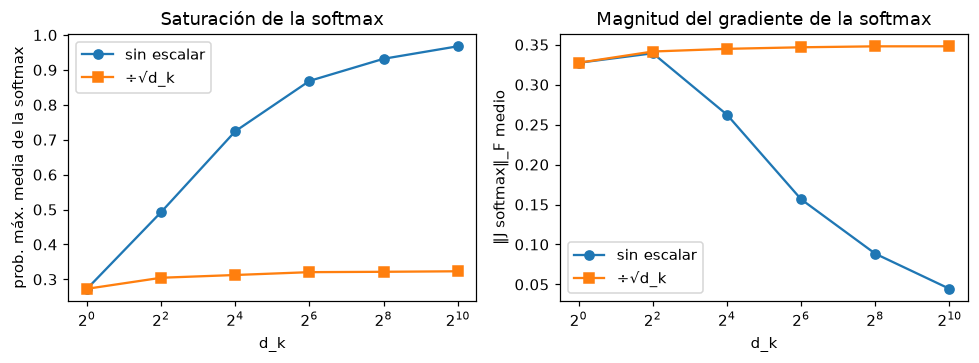

In [3]:
rng = np.random.default_rng(0)
dks = [1, 4, 16, 64, 256, 1024]
N = 20000
rows = []
for d in dks:
    q = rng.standard_normal((N, d)); k = rng.standard_normal((N, d))
    dots = (q*k).sum(1)
    rows.append((d, dots.var(), (dots/np.sqrt(d)).var()))
print(f"{'d_k':>6} {'Var(q.k)':>12} {'Var(q.k/sqrt(d_k))':>20}")
for d, v1, v2 in rows:
    print(f"{d:>6} {v1:>12.3f} {v2:>20.3f}")

# Saturacion de la softmax: n=10 llaves, 1 query
n = 10
res = {"d_k": [], "max_sin": [], "max_con": [], "grad_sin": [], "grad_con": []}
for d in dks:
    q = torch.randn(2000, 1, d); k = torch.randn(2000, n, d)
    for scaled in (False, True):
        s = q @ k.transpose(1,2)
        s = s / math.sqrt(d) if scaled else s
        s = s.detach().requires_grad_(True)
        p = torch.softmax(s, -1)
        # norma del jacobiano de la softmax respecto a s, promedio: ||diag(p)-pp^T||_F
        J = torch.diag_embed(p) - p.unsqueeze(-1)*p.unsqueeze(-2)
        gnorm = J.flatten(1).norm(dim=1).mean().item()
        key = "con" if scaled else "sin"
        res[f"max_{key}"].append(p.max(-1).values.mean().item())
        res[f"grad_{key}"].append(gnorm)
    res["d_k"].append(d)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].plot(res["d_k"], res["max_sin"], "o-", label="sin escalar")
ax[0].plot(res["d_k"], res["max_con"], "s-", label="÷√d_k")
ax[0].set_xscale("log", base=2); ax[0].set_xlabel("d_k"); ax[0].set_ylabel("prob. máx. media de la softmax")
ax[0].legend(); ax[0].set_title("Saturación de la softmax")
ax[1].plot(res["d_k"], res["grad_sin"], "o-", label="sin escalar")
ax[1].plot(res["d_k"], res["grad_con"], "s-", label="÷√d_k")
ax[1].set_xscale("log", base=2); ax[1].set_xlabel("d_k"); ax[1].set_ylabel("‖J softmax‖_F medio")
ax[1].legend(); ax[1].set_title("Magnitud del gradiente de la softmax")
plt.tight_layout(); plt.savefig("figs/escalamiento_sqrt_dk.png", bbox_inches="tight"); plt.show()

## 3. Atención en PyTorch
Ejemplos mínimos de las funciones y clases pedidas en la sección 4 de la guía.

In [4]:
B, n, d = 2, 6, 16
q = torch.randn(B, n, d); k = torch.randn(B, n, d); v = torch.randn(B, n, d)

# 3.1 F.scaled_dot_product_attention vs implementacion manual
def manual_attn(q, k, v, causal=False, scale=None):
    scale = scale or 1/math.sqrt(q.size(-1))
    s = q @ k.transpose(-2, -1) * scale
    if causal:
        m = torch.triu(torch.ones(s.size(-2), s.size(-1), dtype=torch.bool), 1)
        s = s.masked_fill(m, float("-inf"))
    return torch.softmax(s, -1) @ v

for causal in (False, True):
    a = F.scaled_dot_product_attention(q, k, v, is_causal=causal)
    b = manual_attn(q, k, v, causal)
    print(f"SDPA vs manual (is_causal={causal}): max diff = {(a-b).abs().max():.2e}")

# attn_mask booleana (True = puede atender) y scale personalizado
bool_mask = torch.ones(n, n, dtype=torch.bool).tril()
a = F.scaled_dot_product_attention(q, k, v, attn_mask=bool_mask)
print("attn_mask booleana == is_causal:", torch.allclose(a, F.scaled_dot_product_attention(q,k,v,is_causal=True), atol=1e-6))
a_scale = F.scaled_dot_product_attention(q, k, v, scale=1.0)
print("scale=1.0 (sin escalar) difiere del default:", not torch.allclose(a_scale, F.scaled_dot_product_attention(q,k,v)))

# 3.2 nn.MultiheadAttention
mha = nn.MultiheadAttention(embed_dim=d, num_heads=4, batch_first=True)
kpm_bool = torch.zeros(B, n, dtype=torch.bool); kpm_bool[1, -2:] = True   # True = ignorar (padding)
kpm = torch.zeros(B, n).masked_fill(kpm_bool, float('-inf'))            # mismo tipo (float) que attn_mask
cm = nn.Transformer.generate_square_subsequent_mask(n)               # -inf arriba de la diagonal
out, w_avg = mha(q, k, v, key_padding_mask=kpm, attn_mask=cm, need_weights=True)                 # average_attn_weights=True
out, w_all = mha(q, k, v, key_padding_mask=kpm, attn_mask=cm, need_weights=True, average_attn_weights=False)
print("\nmask causal generada:\n", cm)
print("salida:", tuple(out.shape), "| pesos promediados:", tuple(w_avg.shape), "| pesos por cabeza:", tuple(w_all.shape))
print("params MHA (h=4):", sum(p.numel() for p in mha.parameters()),
      "| params MHA (h=1):", sum(p.numel() for p in nn.MultiheadAttention(d, 1, batch_first=True).parameters()),
      "-> el numero de cabezas NO cambia los parametros")

# kdim / vdim distintos (cross-attention con memoria de otra dimension)
mha_x = nn.MultiheadAttention(embed_dim=d, num_heads=4, kdim=24, vdim=24, batch_first=True)
mem = torch.randn(B, 9, 24)
o, w = mha_x(q, mem, mem)
print("cross-attention:", tuple(o.shape), tuple(w.shape))

# 3.3 nn.TransformerEncoderLayer: Post-LN vs Pre-LN
post = nn.TransformerEncoderLayer(d_model=d, nhead=4, dim_feedforward=64, dropout=0.0, batch_first=True, norm_first=False)
pre  = nn.TransformerEncoderLayer(d_model=d, nhead=4, dim_feedforward=64, dropout=0.0, batch_first=True, norm_first=True)
x = torch.randn(B, n, d)
print("\nTransformerEncoderLayer salida:", tuple(post(x).shape), tuple(pre(x, src_mask=cm, is_causal=True).shape))

SDPA vs manual (is_causal=False): max diff = 2.38e-07
SDPA vs manual (is_causal=True): max diff = 1.19e-07
attn_mask booleana == is_causal: True
scale=1.0 (sin escalar) difiere del default: True



mask causal generada:
 tensor([[0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0.]])
salida: (2, 6, 16) | pesos promediados: (2, 6, 6) | pesos por cabeza: (2, 4, 6, 6)
params MHA (h=4): 1088 | params MHA (h=1): 1088 -> el numero de cabezas NO cambia los parametros
cross-attention: (2, 6, 16) (2, 6, 9)

TransformerEncoderLayer salida: (2, 6, 16) (2, 6, 16)


## 4. Costo computacional
La atención estándar materializa una matriz n×n: tiempo $O(n^2 d)$ y memoria $O(n^2)$ por cabeza.
Medimos tiempo y memoria de la matriz de puntajes con una implementación ingenua y la comparamos con `F.scaled_dot_product_attention` (que puede usar kernels tipo FlashAttention en GPU).

device: cpu


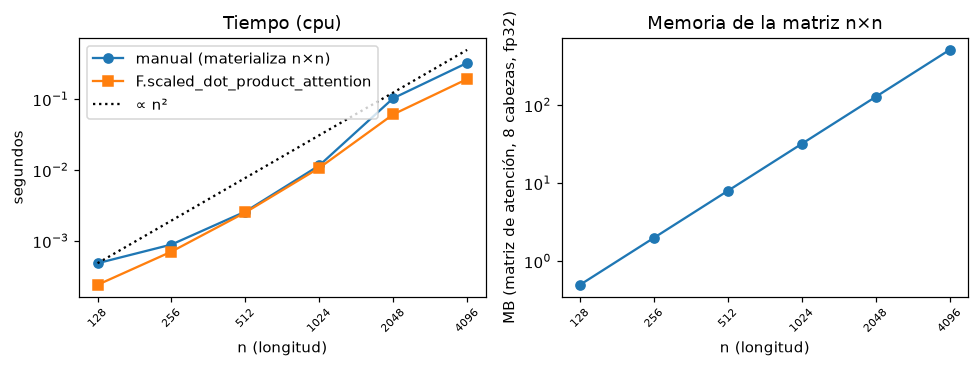

n=  128  manual=    0.49 ms  sdpa=    0.24 ms  mem(n×n)=     0.5 MB
n=  256  manual=    0.89 ms  sdpa=    0.71 ms  mem(n×n)=     2.0 MB
n=  512  manual=    2.61 ms  sdpa=    2.54 ms  mem(n×n)=     8.0 MB
n= 1024  manual=   11.67 ms  sdpa=   10.78 ms  mem(n×n)=    32.0 MB
n= 2048  manual=  103.66 ms  sdpa=   61.38 ms  mem(n×n)=   128.0 MB
n= 4096  manual=  326.89 ms  sdpa=  193.23 ms  mem(n×n)=   512.0 MB

Para n=100,000 una sola cabeza fp32 ocuparía 37.3 GiB solo en la matriz de atención.


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
d_head, heads, B = 64, 8, 1
ns = [128, 256, 512, 1024, 2048, 4096]
t_naive, t_sdpa = [], []

def bench(fn, reps=3):
    fn()
    if device == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(reps): fn()
    if device == "cuda": torch.cuda.synchronize()
    return (time.perf_counter()-t0)/reps

for n in ns:
    q = torch.randn(B, heads, n, d_head, device=device); k = torch.randn_like(q); v = torch.randn_like(q)
    t_naive.append(bench(lambda: manual_attn(q, k, v)))
    t_sdpa.append(bench(lambda: F.scaled_dot_product_attention(q, k, v)))

# memoria teorica de la matriz de atencion (float32, todas las cabezas)
mem_mb = [heads*n*n*4/2**20 for n in ns]

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].loglog(ns, t_naive, "o-", label="manual (materializa n×n)")
ax[0].loglog(ns, t_sdpa, "s-", label="F.scaled_dot_product_attention")
ref = [t_naive[0]*(n/ns[0])**2 for n in ns]
ax[0].loglog(ns, ref, "k:", label="∝ n²")
ax[0].set_xlabel("n (longitud)"); ax[0].set_ylabel("segundos"); ax[0].legend(); ax[0].set_title(f"Tiempo ({device})")
ax[1].loglog(ns, mem_mb, "o-")
ax[1].set_xlabel("n (longitud)"); ax[1].set_ylabel("MB (matriz de atención, 8 cabezas, fp32)"); ax[1].set_title("Memoria de la matriz n×n")
for a_ in (ax[0], ax[1]):
    a_.set_xticks(ns); a_.set_xticklabels(ns, rotation=45, fontsize=7); a_.minorticks_off()
plt.tight_layout(); plt.savefig("figs/costo_computacional.png", bbox_inches="tight"); plt.show()
for n, a, b, m in zip(ns, t_naive, t_sdpa, mem_mb):
    print(f"n={n:5d}  manual={a*1e3:8.2f} ms  sdpa={b*1e3:8.2f} ms  mem(n×n)={m:8.1f} MB")
print("\nPara n=100,000 una sola cabeza fp32 ocuparía", f"{100_000**2*4/2**30:.1f} GiB", "solo en la matriz de atención.")

## 5. Visualización de atención en BERT y GPT-2
Requiere descargar los modelos. `attn_implementation="eager"` es necesario para que `output_attentions=True` devuelva los pesos.

In [6]:
from transformers import AutoTokenizer, AutoModel

tok_bert = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased", output_attentions=True, attn_implementation="eager").eval()
tok_gpt2 = AutoTokenizer.from_pretrained("gpt2")
gpt2 = AutoModel.from_pretrained("gpt2", output_attentions=True, attn_implementation="eager").eval()

@torch.no_grad()
def get_attn(model, tok, text):
    enc = tok(text, return_tensors="pt")
    out = model(**enc)
    att = torch.stack(out.attentions)[:, 0].numpy()      # (capas, cabezas, n, n)
    toks = tok.convert_ids_to_tokens(enc["input_ids"][0])
    toks = [t.replace("Ġ", "") for t in toks]
    return att, toks

sent = "The animal didn't cross the street because it was too tired."
att_b, toks_b = get_attn(bert, tok_bert, sent)
att_g, toks_g = get_attn(gpt2, tok_gpt2, sent)
print("BERT:", att_b.shape, toks_b)
print("GPT-2:", att_g.shape, toks_g)

C:\Users\melis\Documents\noCuarentena\semestre 8\deep\deep_hoja2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BERT: (12, 12, 16, 16) ['[CLS]', 'the', 'animal', 'didn', "'", 't', 'cross', 'the', 'street', 'because', 'it', 'was', 'too', 'tired', '.', '[SEP]']
GPT-2: (12, 12, 13, 13) ['The', 'animal', 'didn', "'t", 'cross', 'the', 'street', 'because', 'it', 'was', 'too', 'tired', '.']


### 5.1 Mapas de calor de 4 cabezas de capas distintas

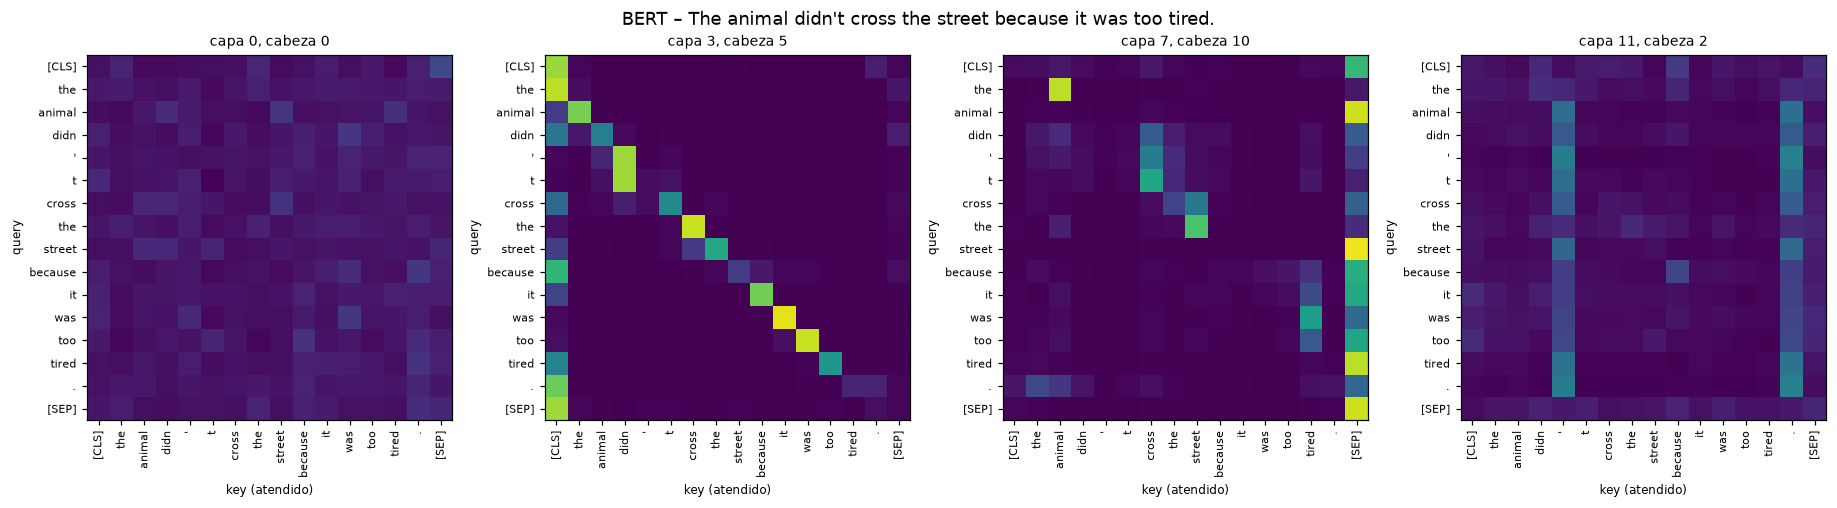

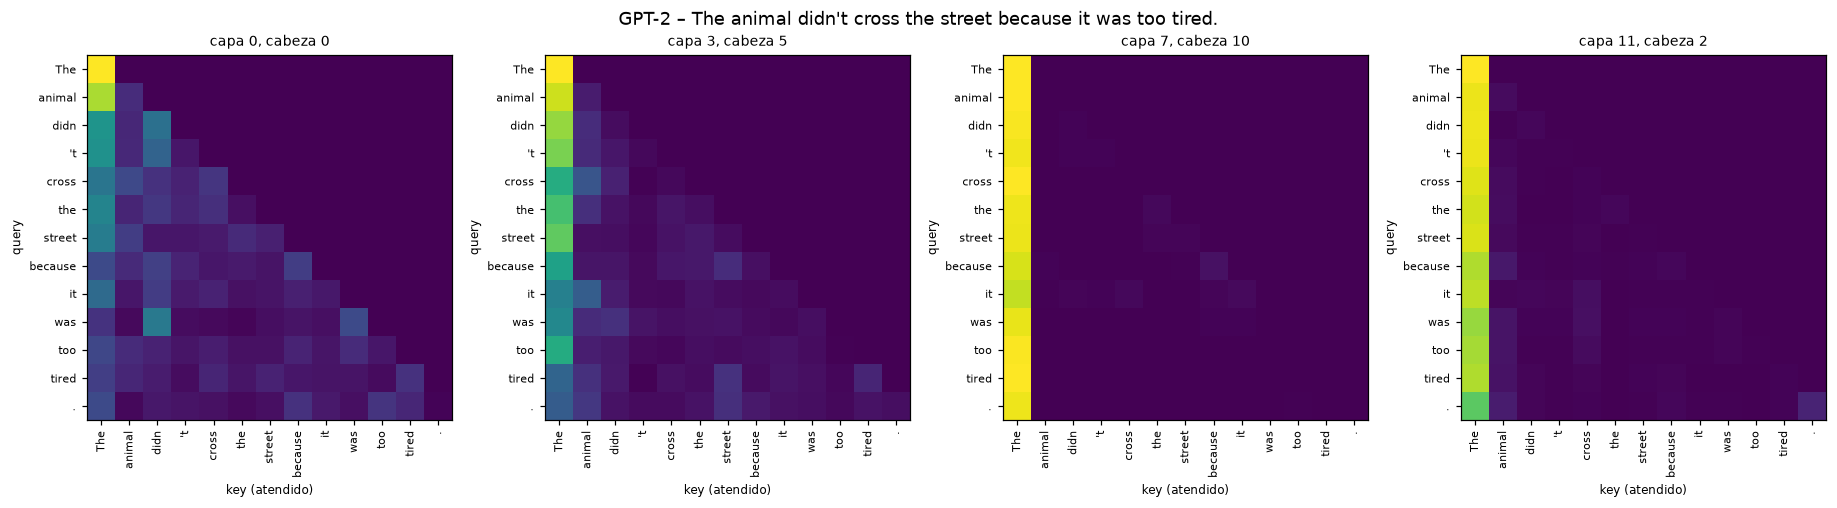

In [7]:
def plot_heads(att, toks, picks, title, fname):
    fig, axes = plt.subplots(1, len(picks), figsize=(4.2*len(picks), 4.4))
    for ax, (l, h) in zip(np.atleast_1d(axes), picks):
        ax.imshow(att[l, h], cmap="viridis", vmin=0, vmax=1)
        ax.set_xticks(range(len(toks))); ax.set_xticklabels(toks, rotation=90, fontsize=7)
        ax.set_yticks(range(len(toks))); ax.set_yticklabels(toks, fontsize=7)
        ax.set_title(f"capa {l}, cabeza {h}", fontsize=9)
        ax.set_xlabel("key (atendido)", fontsize=8); ax.set_ylabel("query", fontsize=8)
    fig.suptitle(title); plt.tight_layout(); plt.savefig(fname, bbox_inches="tight"); plt.show()

# Cambia estas (capa, cabeza) para explorar; los siguientes valores son un punto de partida
picks = [(0, 0), (3, 5), (7, 10), (11, 2)]
plot_heads(att_b, toks_b, picks, "BERT – " + sent, "figs/bert_heads.png")
plot_heads(att_g, toks_g, picks, "GPT-2 – " + sent, "figs/gpt2_heads.png")

In [8]:
# Ayuda para identificar patrones automaticamente: que fraccion de la atencion de cada cabeza
# cae en (a) token anterior, (b) token siguiente, (c) [CLS]/primer token, (d) [SEP]/puntuacion, (e) el mismo token
def head_patterns(att, toks, bert_like=True):
    L, H, n, _ = att.shape
    idx = np.arange(n)
    def frac(mask): return (att * mask).sum(-1).mean(-1)          # (L,H): media sobre queries
    prev = (idx[None,:] == idx[:,None]-1).astype(float)
    nxt  = (idx[None,:] == idx[:,None]+1).astype(float)
    same = np.eye(n)
    first = np.zeros((n,n)); first[:,0] = 1
    punct = np.zeros((n,n))
    for j,t in enumerate(toks):
        if t in ("[SEP]", ".", ",", "?", "!"): punct[:, j] = 1
    return {"anterior": frac(prev), "siguiente": frac(nxt), "mismo": frac(same),
            "primer token": frac(first), "[SEP]/puntuación": frac(punct)}

for name, att, toks in (("BERT", att_b, toks_b), ("GPT-2", att_g, toks_g)):
    pats = head_patterns(att, toks)
    print(f"\n== {name}: cabezas con mayor proporción por patrón ==")
    for p, M in pats.items():
        l, h = np.unravel_index(M.argmax(), M.shape)
        print(f"  {p:18s} -> capa {l:2d}, cabeza {h:2d}  (fracción media = {M.max():.2f})")


== BERT: cabezas con mayor proporción por patrón ==
  anterior           -> capa  3, cabeza  5  (fracción media = 0.53)
  siguiente          -> capa  2, cabeza  9  (fracción media = 0.88)
  mismo              -> capa  2, cabeza  6  (fracción media = 0.45)
  primer token       -> capa  1, cabeza  6  (fracción media = 0.95)
  [SEP]/puntuación   -> capa  5, cabeza  1  (fracción media = 0.93)

== GPT-2: cabezas con mayor proporción por patrón ==
  anterior           -> capa  4, cabeza 11  (fracción media = 0.92)
  siguiente          -> capa  0, cabeza  0  (fracción media = 0.00)
  mismo              -> capa  0, cabeza  1  (fracción media = 0.97)
  primer token       -> capa  5, cabeza  1  (fracción media = 1.00)
  [SEP]/puntuación   -> capa  0, cabeza  1  (fracción media = 0.08)


### 5.2 BERT: ¿«it» atiende a «animal» o a «street» según el final de la oración?

capa  cab | tired: it→animal  it→street |  wide: it→animal  it→street
   6   10 |            0.284      0.067 |            0.012      0.590
   8   10 |            0.676      0.000 |            0.309      0.259
   9    8 |            0.454      0.003 |            0.023      0.045
   9    0 |            0.608      0.002 |            0.255      0.074
  10    8 |            0.564      0.001 |            0.245      0.078
   8    4 |            0.242      0.014 |            0.046      0.209
   4   10 |            0.333      0.095 |            0.167      0.288
  10    6 |            0.714      0.008 |            0.490      0.108


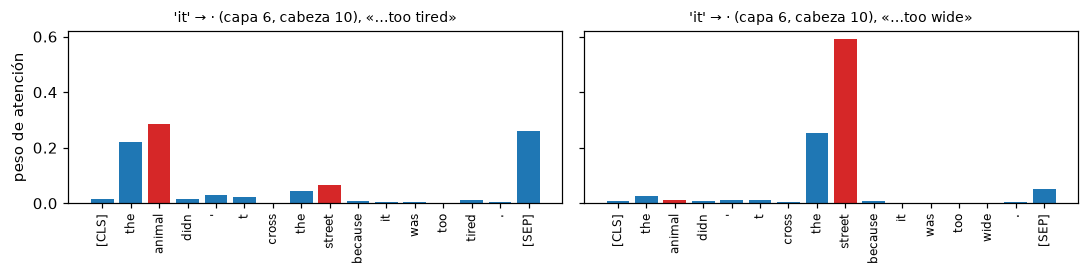


Nota: si ninguna cabeza muestra una inversión clara, ese es un resultado válido y se discute en el informe.


In [9]:
s_tired = "The animal didn't cross the street because it was too tired."
s_wide  = "The animal didn't cross the street because it was too wide."
A_t, T_t = get_attn(bert, tok_bert, s_tired)
A_w, T_w = get_attn(bert, tok_bert, s_wide)
i_it, i_an, i_st = T_t.index("it"), T_t.index("animal"), T_t.index("street")
assert (T_w.index("it"), T_w.index("animal"), T_w.index("street")) == (i_it, i_an, i_st)

# score por cabeza: a(it->animal) - a(it->street), en cada oracion
d_t = A_t[:, :, i_it, i_an] - A_t[:, :, i_it, i_st]     # >0: prefiere animal
d_w = A_w[:, :, i_it, i_an] - A_w[:, :, i_it, i_st]
flip = d_t - d_w                                         # grande: animal en 'tired' y street en 'wide'
order = np.dstack(np.unravel_index(np.argsort(-flip.ravel()), flip.shape))[0][:8]
print(f"{'capa':>4} {'cab':>4} | {'tired: it→animal':>16} {'it→street':>10} | {'wide: it→animal':>16} {'it→street':>10}")
for l, h in order:
    print(f"{l:>4} {h:>4} | {A_t[l,h,i_it,i_an]:>16.3f} {A_t[l,h,i_it,i_st]:>10.3f} | {A_w[l,h,i_it,i_an]:>16.3f} {A_w[l,h,i_it,i_st]:>10.3f}")

l, h = order[0]
fig, ax = plt.subplots(1, 2, figsize=(10, 2.6), sharey=True)
for a, A, T, s in zip(ax, (A_t, A_w), (T_t, T_w), ("tired", "wide")):
    a.bar(range(len(T)), A[l, h, i_it], color=["C3" if j in (i_an, i_st) else "C0" for j in range(len(T))])
    a.set_xticks(range(len(T))); a.set_xticklabels(T, rotation=90, fontsize=8)
    a.set_title(f"'it' → · (capa {l}, cabeza {h}), «…too {s}»", fontsize=9)
ax[0].set_ylabel("peso de atención"); plt.tight_layout()
plt.savefig("figs/bert_it_animal_street.png", bbox_inches="tight"); plt.show()
print("\nNota: si ninguna cabeza muestra una inversión clara, ese es un resultado válido y se discute en el informe.")

### 5.3 GPT-2: triangularidad y *attention sink* (Xiao et al., 2023, arXiv:2309.17453)

max de la parte triangular superior (debe ser 0):

 0.0


capa  0:  22.8%
capa  1:  39.6%
capa  2:  40.2%
capa  3:  54.7%
capa  4:  57.1%
capa  5:  75.3%
capa  6:  72.2%
capa  7:  81.9%
capa  8:  75.3%
capa  9:  82.3%
capa 10:  82.5%
capa 11:  67.4%


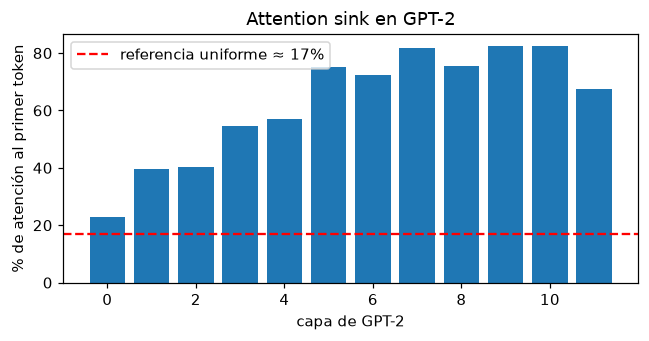

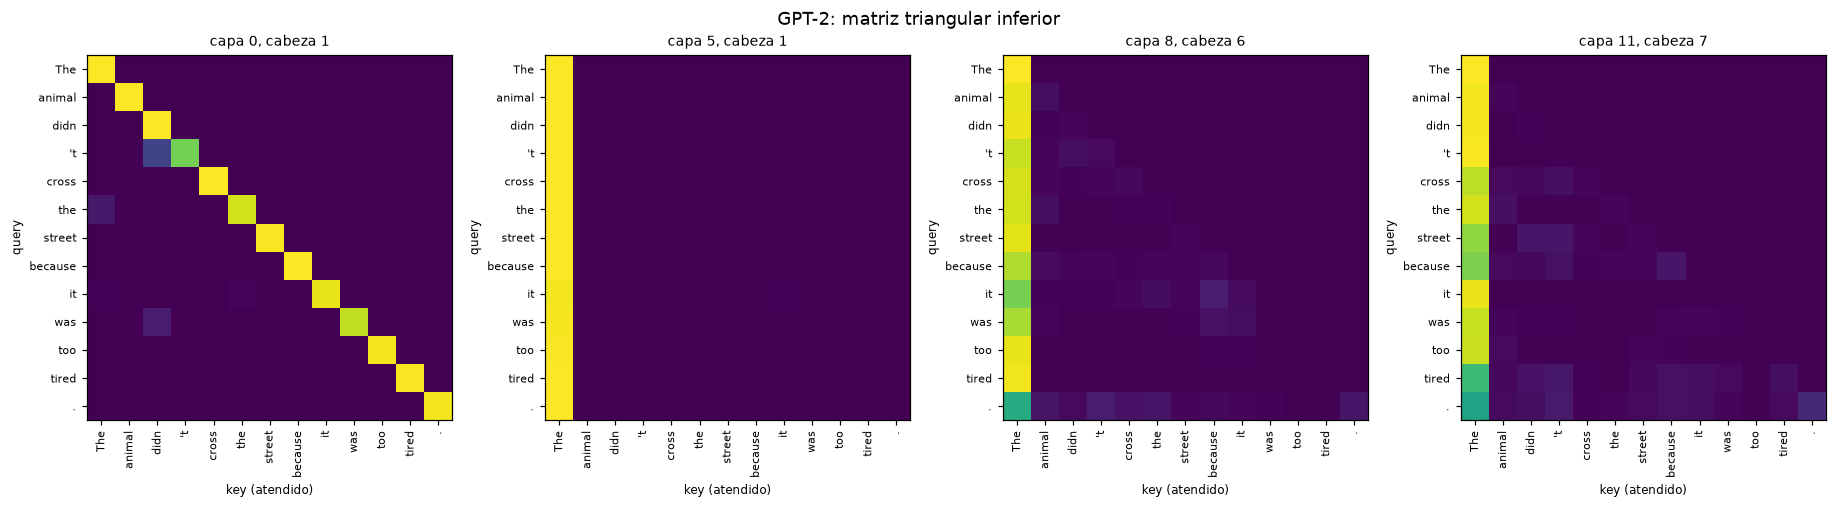

In [10]:
sents = [
    "The animal didn't cross the street because it was too tired.",
    "The quick brown fox jumps over the lazy dog while the cat watches from the fence.",
    "Attention is all you need to understand how modern language models process text.",
    "In 2017 researchers at Google introduced the Transformer architecture for machine translation.",
    "She opened the old book and began to read the first chapter slowly.",
]
# a) triangular inferior
up = max(np.triu(get_attn(gpt2, tok_gpt2, s)[0], 1).max() for s in sents)
print("max de la parte triangular superior (debe ser 0):", up)

# b) proporcion de atencion que recibe el primer token, por capa (media sobre cabezas y queries i>0)
def first_tok_share(att):
    return att[:, :, 1:, 0].mean(axis=(1, 2))              # (capas,)
shares = np.mean([first_tok_share(get_attn(gpt2, tok_gpt2, s)[0]) for s in sents], axis=0)
# referencia uniforme: si la atencion fuera uniforme sobre el pasado, el primer token recibiria 1/(i+1)
def uniform_ref(n): return np.mean([1/(i+1) for i in range(1, n)])
ref = np.mean([uniform_ref(len(get_attn(gpt2, tok_gpt2, s)[1])) for s in sents])
for l, s in enumerate(shares): print(f"capa {l:2d}: {s*100:5.1f}%")
plt.figure(figsize=(6, 3.2)); plt.bar(range(12), shares*100)
plt.axhline(ref*100, color="r", ls="--", label=f"referencia uniforme ≈ {ref*100:.0f}%")
plt.xlabel("capa de GPT-2"); plt.ylabel("% de atención al primer token"); plt.legend()
plt.title("Attention sink en GPT-2"); plt.tight_layout(); plt.savefig("figs/gpt2_first_token.png", bbox_inches="tight"); plt.show()

# c) visualizacion de la triangularidad
plot_heads(att_g, toks_g, [(0, 1), (5, 1), (8, 6), (11, 7)], "GPT-2: matriz triangular inferior", "figs/gpt2_triangular.png")

### 5.4 Entropía promedio de la atención por capa (BERT vs. GPT-2)

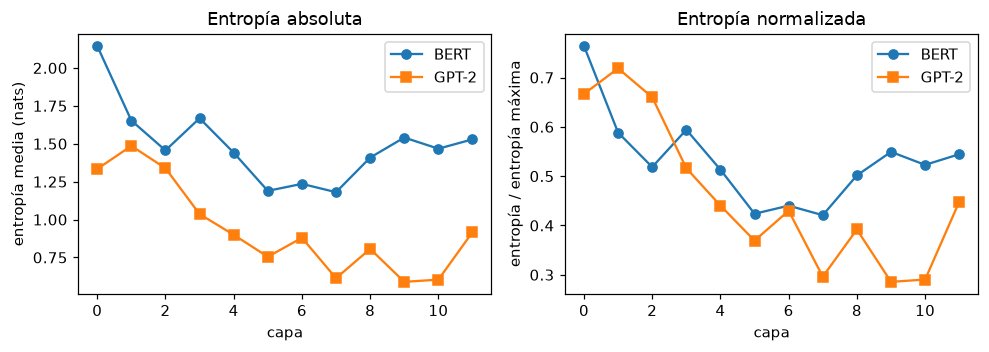

capa  BERT   GPT-2   (entropía normalizada)
   0  0.764  0.667
   1  0.588  0.719
   2  0.518  0.660
   3  0.594  0.516
   4  0.513  0.440
   5  0.424  0.369
   6  0.440  0.430
   7  0.421  0.296
   8  0.502  0.392
   9  0.549  0.286
  10  0.523  0.290
  11  0.544  0.448


In [11]:
def layer_entropy(att, causal=False):
    # H(i) = -sum_j a_ij log a_ij ; media sobre cabezas y queries
    a = np.clip(att, 1e-12, 1)
    H = -(att * np.log(a)).sum(-1)                         # (L,H,n)
    Hn = H.copy()
    if causal:                                             # normalizada por log(i+1): maximo posible en la fila i
        n = att.shape[-1]; Hn = H[..., 1:] / np.log(np.arange(2, n+1))
        H = H[..., 1:]
    else:
        Hn = H / np.log(att.shape[-1])
    return H.mean(axis=(1, 2)), Hn.mean(axis=(1, 2))

Eb, Ebn = zip(*[layer_entropy(get_attn(bert, tok_bert, s)[0]) for s in sents])
Eg, Egn = zip(*[layer_entropy(get_attn(gpt2, tok_gpt2, s)[0], causal=True) for s in sents])
Eb, Ebn, Eg, Egn = map(lambda x: np.mean(x, 0), (Eb, Ebn, Eg, Egn))

fig, ax = plt.subplots(1, 2, figsize=(9, 3.3))
ax[0].plot(range(12), Eb, "o-", label="BERT"); ax[0].plot(range(12), Eg, "s-", label="GPT-2")
ax[0].set_xlabel("capa"); ax[0].set_ylabel("entropía media (nats)"); ax[0].legend(); ax[0].set_title("Entropía absoluta")
ax[1].plot(range(12), Ebn, "o-", label="BERT"); ax[1].plot(range(12), Egn, "s-", label="GPT-2")
ax[1].set_xlabel("capa"); ax[1].set_ylabel("entropía / entropía máxima"); ax[1].legend(); ax[1].set_title("Entropía normalizada")
plt.tight_layout(); plt.savefig("figs/entropia_por_capa.png", bbox_inches="tight"); plt.show()
print("capa  BERT   GPT-2   (entropía normalizada)")
for l in range(12): print(f"{l:4d}  {Ebn[l]:.3f}  {Egn[l]:.3f}")